# Random Forest Classifier

This notebook will explore the use of random forests to predict hyper- and hypothyroid conditions.

## Import Packages

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, recall_score, make_scorer
from sklearn.preprocessing import StandardScaler

## Read In Data

In [2]:
X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')
y_train = np.array(pd.read_csv('train_labels.csv')).reshape(7333,)
y_test = np.array(pd.read_csv('test_labels.csv')).reshape(1834,)

## Scale Data

In [3]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

## Run RF Classifier

### Tune Num Trees

In [4]:
def score(y_true, y_pred):
    return np.array(recall_score(y_true, y_pred, average=None)).min()

In [5]:
num_trees = range(10, 501, 10)
scores = []
for n in num_trees:
    rf = RandomForestClassifier(random_state=6740, n_estimators=n)
    scores.append(cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring=make_scorer(score)).mean())

In [6]:
scores = np.array(scores)
best_n = num_trees[np.where(scores == scores.max())[0][0]]
best_n_recall = scores[np.where(scores == scores.max())[0][0]]
print(f'The best number of trees is {best_n} with a recall of {best_n_recall:.4f}') 

The best number of trees is 330 with a recall of 0.5752


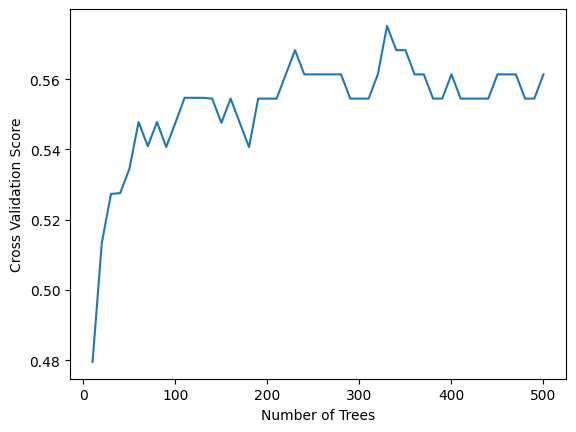

In [7]:
plt.plot(num_trees, scores)
plt.xlabel('Number of Trees')
plt.ylabel('Cross Validation Score')
plt.show()

### Use best_n trees

In [8]:
rf = RandomForestClassifier(random_state=6740, n_estimators=best_n)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1679
           1       0.96      0.95      0.95       119
           2       0.88      0.61      0.72        36

    accuracy                           0.98      1834
   macro avg       0.94      0.85      0.89      1834
weighted avg       0.98      0.98      0.98      1834



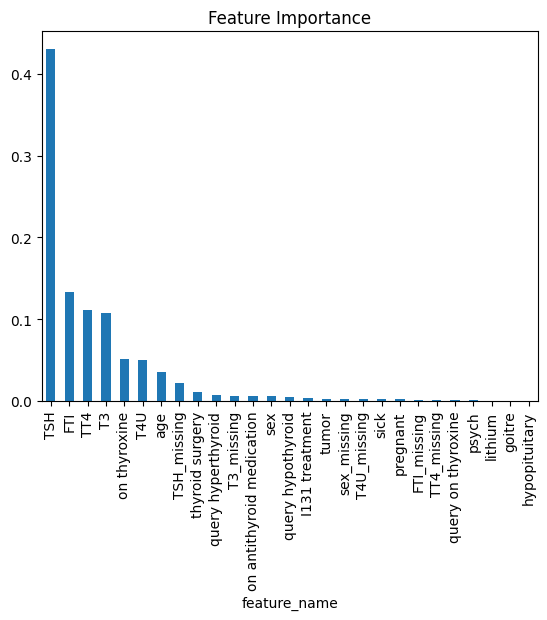

In [9]:
feature_importance_df = pd.DataFrame({'feature': rf.feature_importances_, 'feature_name': X_train.columns}).sort_values(by='feature', ascending=False)
feature_importance_df.plot(kind='bar', x='feature_name', y='feature', legend=False, title='Feature Importance')
plt.show()